# Netflix Data Analysis

This project explores Netflix movies and TV shows dataset to uncover insights related to content distribution, genres, ratings, and trends over time.

## Problem Statement

The objective of this project is to analyze Netflix content data and identify patterns in content type, genres, country distribution, ratings, and growth trends over time.

## Tools and Technologies

- Python
- Pandas (Data Analysis)
- Seaborn & Matplotlib (Visualization)

## Dataset Overview

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Data Cleaning

Missing values were handled by filling categorical columns with 'Unknown'.  
The 'date_added' column was converted to datetime format, and year was extracted for analysis.

In [15]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year'] = df['date_added'].dt.year

## Movies vs TV Shows Analysis

In [ ]:
df['type'].value_counts()

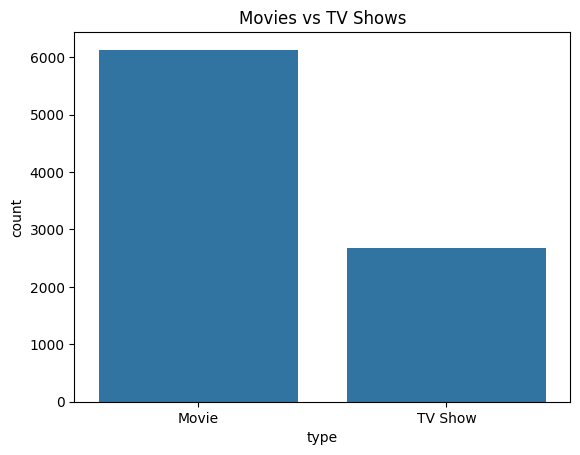

In [4]:

import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

### Insight:
Movies are more prevalent than TV Shows on Netflix.

## Top Countries Producing Content

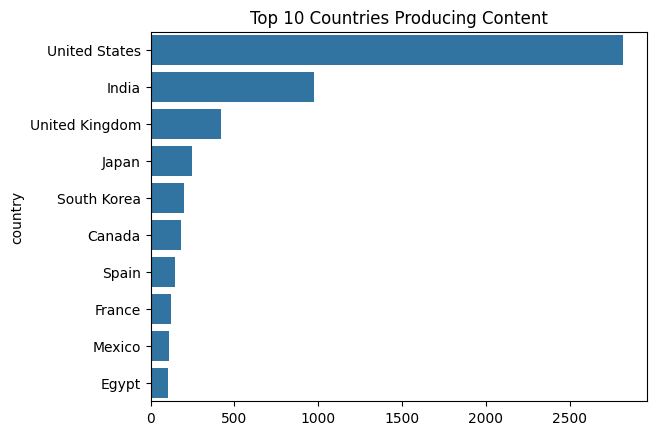

In [6]:

top_countries = df['country'].value_counts().head(10)
top_countries
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries Producing Content")
plt.show()

### Insight:
The United States produces the highest content, followed by India and other countries.

## Content Trend Over Years

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year'] = df['date_added'].dt.year
year=df['year'].value_counts().sort_index()
print(year)

In [ ]:
year = year.dropna()

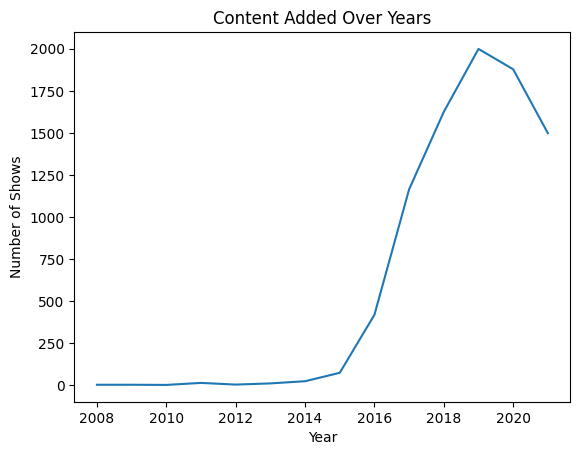

In [9]:
sns.lineplot(x=year.index, y=year.values)
plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Shows")
plt.show()

### Insight:
Content production increased rapidly after 2015, showing Netflix's growth.

## Ratings Analysis

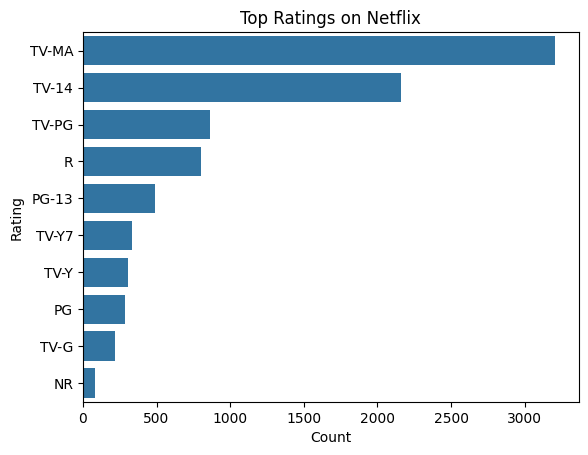

In [10]:
top_ratings=df['rating'].value_counts().head(10)
sns.barplot(x=top_ratings.values, y=top_ratings.index)
plt.title("Top Ratings on Netflix")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.show()

### Insight:
Most content is rated for mature audiences (TV-MA).

## Genre Analysis

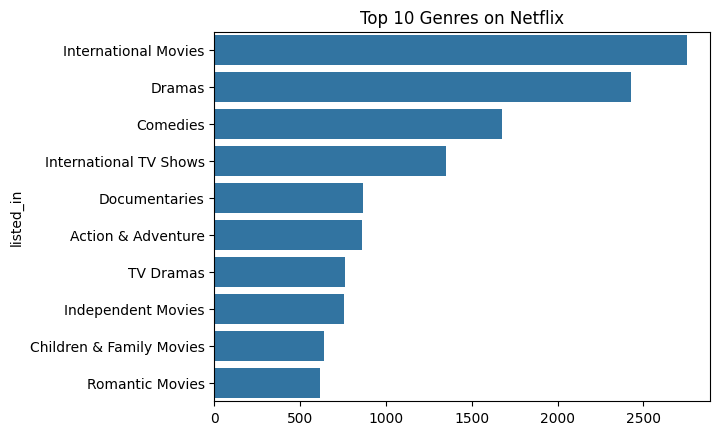

In [13]:
df['listed_in'] = df['listed_in'].str.split(', ')
df_exploded = df.explode('listed_in')
top_genre = df_exploded['listed_in'].value_counts().head(10)
sns.barplot(x=top_genre.values, y=top_genre.index)
plt.title("Top 10 Genres on Netflix")
plt.show()

### Insight:
International Movies is the most common genre, followed by Dramas and Comedies.

## Movies vs TV Shows Analysis

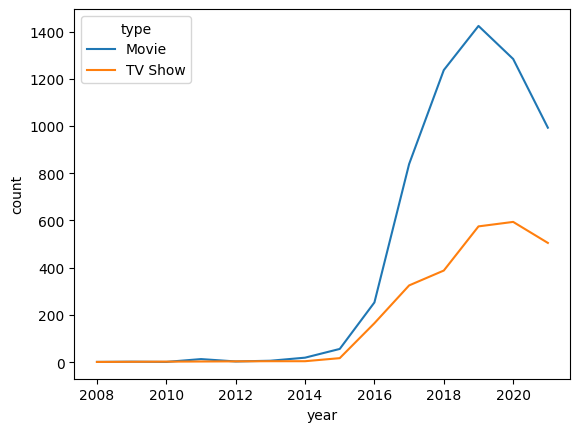

In [14]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year'] = df['date_added'].dt.year
type_year = df.groupby(['year', 'type']).size().reset_index(name='count')

sns.lineplot(data=type_year, x='year', y='count', hue='type')
plt.show()

## Movies vs TV Shows Trend

### Key Insights:
- Content increased rapidly after 2015.
- Movies are more than TV Shows.
- TV Shows show steady growth over time.
- Peak observed around 2019–2020.


## Conclusion

- Netflix has more Movies than TV Shows.
- The United States contributes the most content.
- Content growth increased significantly after 2015.
- International content is highly dominant.
- Drama and International Movies are the most common genres.
- Most content is targeted toward mature audiences.